<a href="https://colab.research.google.com/github/Oscarpuche/practicas_fisica2/blob/main/graficas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

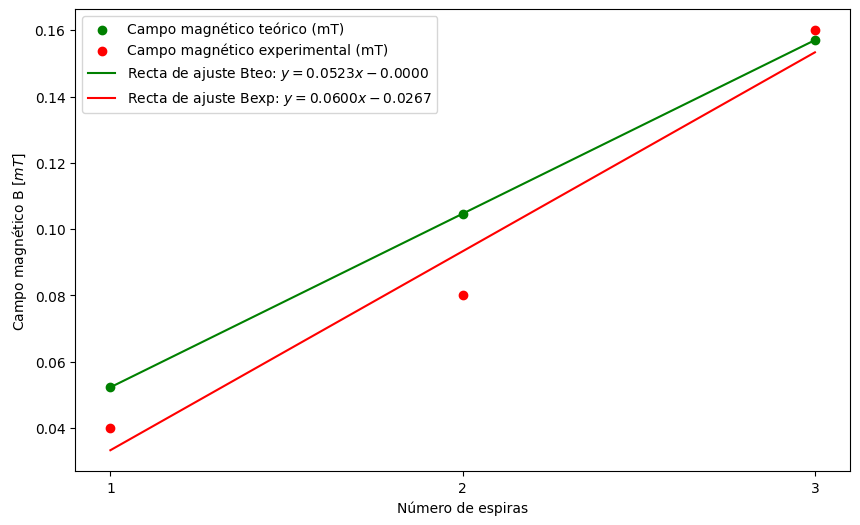

In [1]:
import numpy as np
import matplotlib.pyplot as plt

#Datos del campo magnetico (teorico y experimental)
Bteo = np.array([0.0523,0.1047,0.1570])
Bexp = np.array([0.04,0.08,0.16])

#Número de espiras
nespira = np.array([1,2,3])

# Coeficientes del ajuste lineal
coeficientes1 = np.polyfit(nespira,Bteo, 1)
coeficientes2 = np.polyfit(nespira,Bexp, 1)

#Coeficientes del campo magnetico teorico
a1 = coeficientes1[0]
b1 = coeficientes1[1]

#Coeficientes del campo magnetico experimental
a2 = coeficientes2[0]
b2 = coeficientes2[1]

# Generar puntos de la recta de ajuste para la gráfica
x_fit1 = np.linspace(min(nespira), max(nespira), 100)
y_fit1 = a1 * x_fit1 + b1

x_fit2 = np.linspace(min(nespira), max(nespira), 100)
y_fit2 = a2 * x_fit2 + b2

# Generación del plot
plt.figure(figsize=(10, 6))

# Dibujar los datos experimentales
plt.scatter(nespira, Bteo, color='green', label=r'Campo magnético teórico (mT)', marker='o')
plt.scatter(nespira, Bexp, color='red', label=r'Campo magnético experimental (mT)', marker='o')

# Dibujar la recta de ajuste
plt.plot(x_fit1, y_fit1, color='green', label=f'Recta de ajuste Bteo: $y = {a1:.4f}x {b1:.4f}$', linestyle='-')
plt.plot(x_fit2, y_fit2, color='red', label=f'Recta de ajuste Bexp: $y = {a2:.4f}x {b2:.4f}$', linestyle='-')

# Etiquetas
plt.xlabel('Número de espiras')
plt.ylabel('Campo magnético B $[mT]$')

# Establecer los ticks del eje x para que muestren solo números enteros
plt.xticks(nespira)

# Mostrar leyenda
plt.legend()

# Mostrar el gráfico
plt.show()

[0.94 1.44 1.74 1.83 1.74 1.44 0.94]
[0.96 1.46 1.78 1.93 2.   2.03 2.04 2.03 2.   1.93 1.78 1.46 0.96]
[1.96 2.05 2.1  2.13 2.15 2.15 2.16 2.15 2.15 2.13 2.1  2.05 1.96]


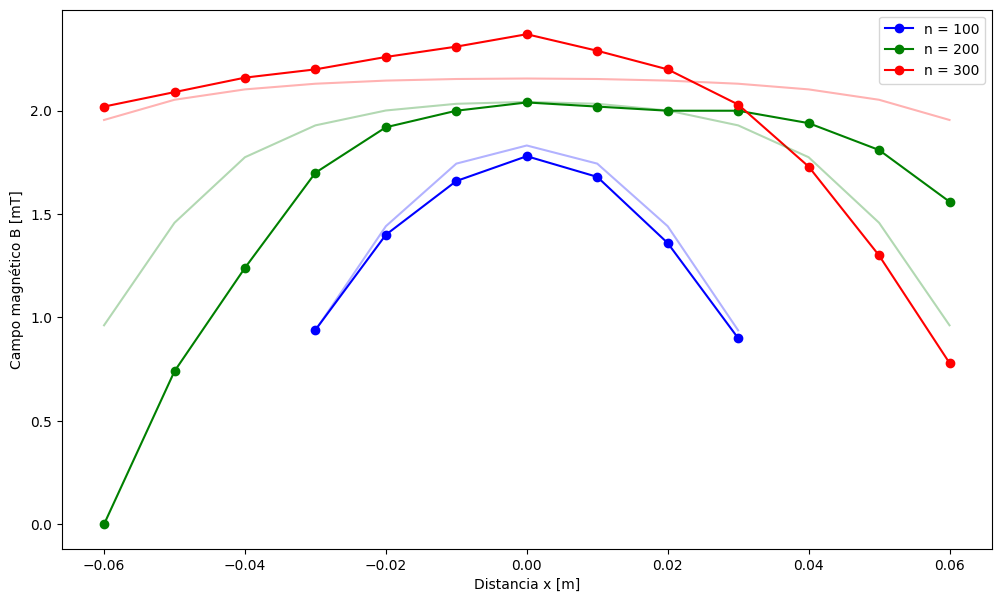

In [2]:
import numpy as np
import matplotlib.pyplot as plt

#Datos del campo magnetico experimental (mT)
Bexp1 = np.array([0.94, 1.40, 1.66, 1.78, 1.68, 1.36, 0.90])
Bexp2 = np.array([0, 0.74, 1.24, 1.70, 1.92, 2.00, 2.04, 2.02, 2.00, 2.00, 1.94, 1.81, 1.56])
Bexp3 = np.array([2.02, 2.09, 2.16, 2.20, 2.26, 2.31, 2.37, 2.29, 2.20, 2.03, 1.73, 1.30, 0.78])

#Definimos el resto de variables necesarias
mu0 = 4*np.pi*10**-7
I2 = 1
l = np.array([55,116,170])/1000
a = (41/2)/(1000)
nespira = np.array([100,200,300])

#Distancias del centro (en metros)
x1 = np.arange(-0.03, 0.031, 0.01)
x2 = np.arange(-0.06, 0.061, 0.01)

#Definimos la expresion del campo magnetico teorico
def magnetico (x, i, nespira, mu0, l, a):
  # Corregido: usar l/2 en lugar de 1/2
  c = x + (l / 2)
  b = x - (l / 2)
  return (i * nespira * mu0 / (2 * l)) * (((c / np.sqrt(a**2 + c**2)) - (b / np.sqrt(a**2 + b**2))))

# Bucle para crear los arrays correspondientes a Bteo
Bteo_list = []
for i in range(len(nespira)):
    dist = x1 if i == 0 else x2
    Bteo_list.append(magnetico(dist, I2, nespira[i], mu0, l[i], a))

# Desempaquetar para mantener compatibilidad con el resto del código
Bteo1, Bteo2, Bteo3 = Bteo_list

#Pasamos los campos magnéticos teóricos a mT
Bteo1 = Bteo1*1000
Bteo2 = Bteo2*1000
Bteo3 = Bteo3*1000

#Imprimimos por pantalla los campos magnéticos teóricos
print(np.round(Bteo1, 2))
print(np.round(Bteo2, 2))
print(np.round(Bteo3, 2))

# Generación del plot
plt.figure(figsize=(12, 7))

# Dibujar los datos experimentales
plt.plot(x1, Bexp1, label='n = 100', marker='o', linestyle='-', color='blue')
plt.plot(x2, Bexp2, label='n = 200', marker='o', linestyle='-', color='green')
plt.plot(x2, Bexp3, label='n = 300', marker='o', linestyle='-', color='red')

# Dibujar los datos teoricos
plt.plot(x1, Bteo1, linestyle='-', color='blue', alpha=0.3)
plt.plot(x2, Bteo2, linestyle='-', color='green', alpha=0.3)
plt.plot(x2, Bteo3, linestyle='-', color='red', alpha=0.3)

#Etiquetas
plt.xlabel('Distancia x [m]')
plt.ylabel('Campo magnético B [mT]')

# Mostrar leyenda
plt.legend()

# Mostrar el gráfico
plt.show()

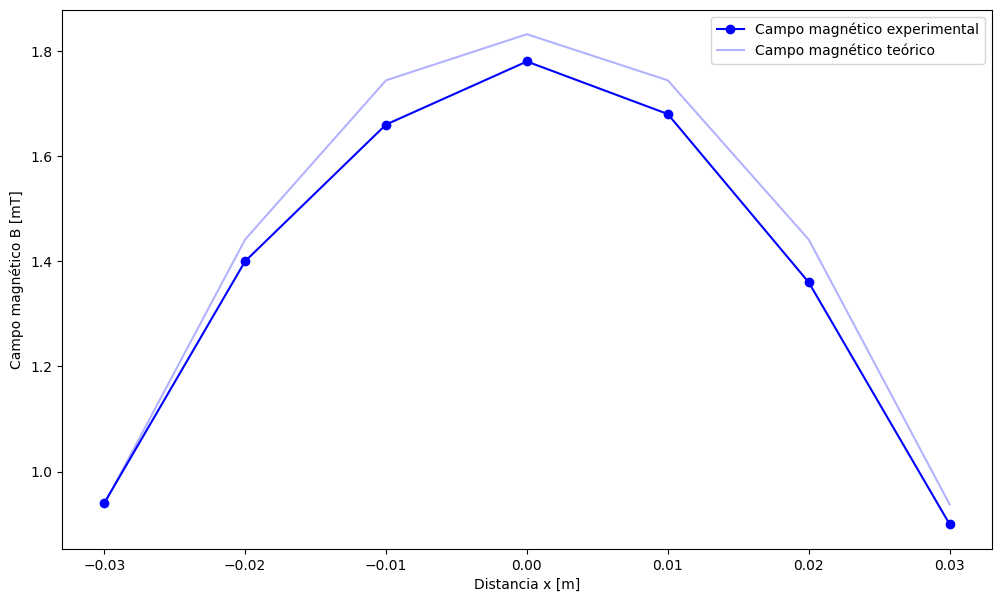

In [3]:
# Generación del plot
plt.figure(figsize=(12, 7))

plt.plot(x1, Bexp1, label='Campo magnético experimental', marker='o', linestyle='-', color='blue')
plt.plot(x1, Bteo1, label='Campo magnético teórico',linestyle='-', color='blue', alpha=0.3)

#Etiquetas
plt.xlabel('Distancia x [m]')
plt.ylabel('Campo magnético B [mT]')

# Mostrar leyenda
plt.legend()

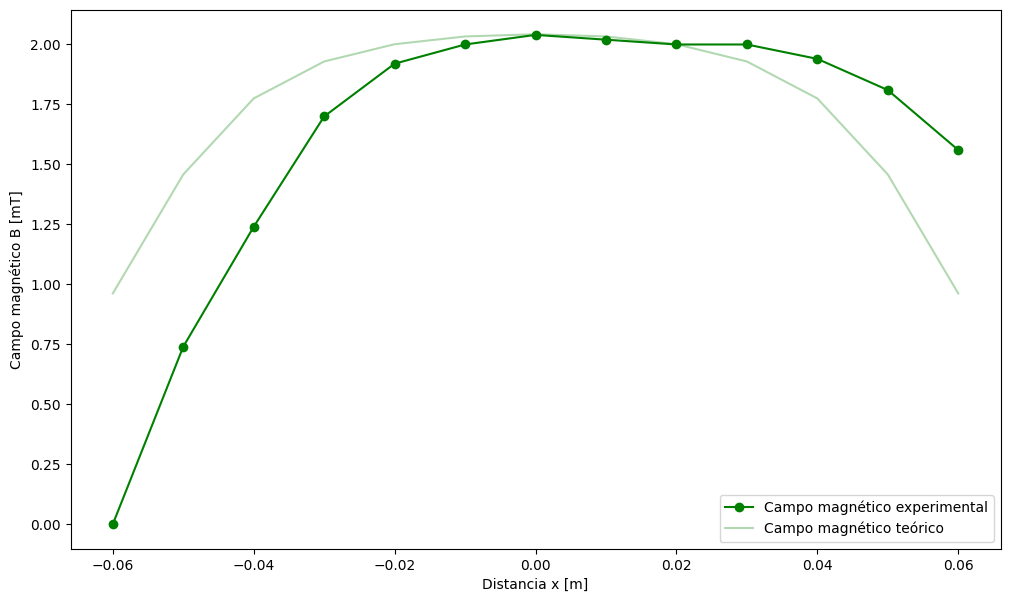

In [4]:
plt.figure(figsize=(12, 7))
plt.plot(x2, Bexp2, label='Campo magnético experimental', marker='o', linestyle='-', color='green')
plt.plot(x2, Bteo2, label='Campo magnético teórico', linestyle='-', color='green', alpha=0.3)

#Etiquetas
plt.xlabel('Distancia x [m]')
plt.ylabel('Campo magnético B [mT]')

# Mostrar leyenda
plt.legend()

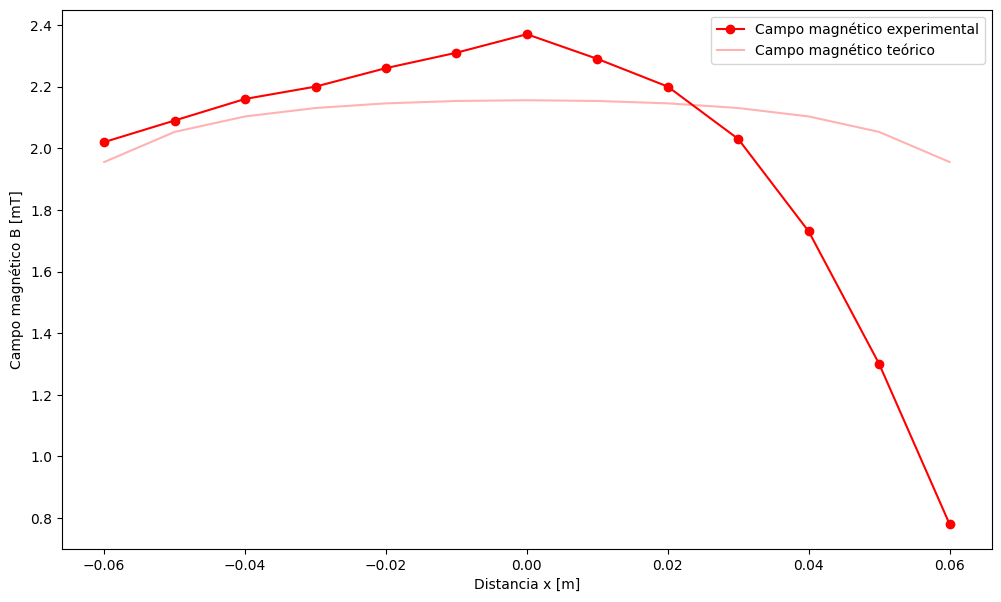

In [5]:
plt.figure(figsize=(12, 7))
plt.plot(x2, Bexp3, label='Campo magnético experimental', marker='o', linestyle='-', color='red')
plt.plot(x2, Bteo3, label='Campo magnético teórico', linestyle='-', color='red', alpha=0.3)

#Etiquetas
plt.xlabel('Distancia x [m]')
plt.ylabel('Campo magnético B [mT]')

# Mostrar leyenda
plt.legend()

In [9]:
def n2 (ient, a, delta):
  return (np.sin(ient)*np.sqrt(((a*np.cos(ient))/(delta-np.sin(ient)*a))**2+1))

ient = np.deg2rad(np.array ([25,37,44]))
a = 6.4/100
delta = np.array ([1.0,1.4,2.2])/100

# Initialize indices as a Python list
indices_list = []

for k in range(len(ient)):
  val = n2(ient[k], a, delta[k])
  print(f"{val:.3f}")
  indices_list.append(val)

# Convert the list to a NumPy array after the loop
indices = np.array(indices_list)

print(f"{np.average(indices):.3f}")


1.499
1.392
1.584
1.492


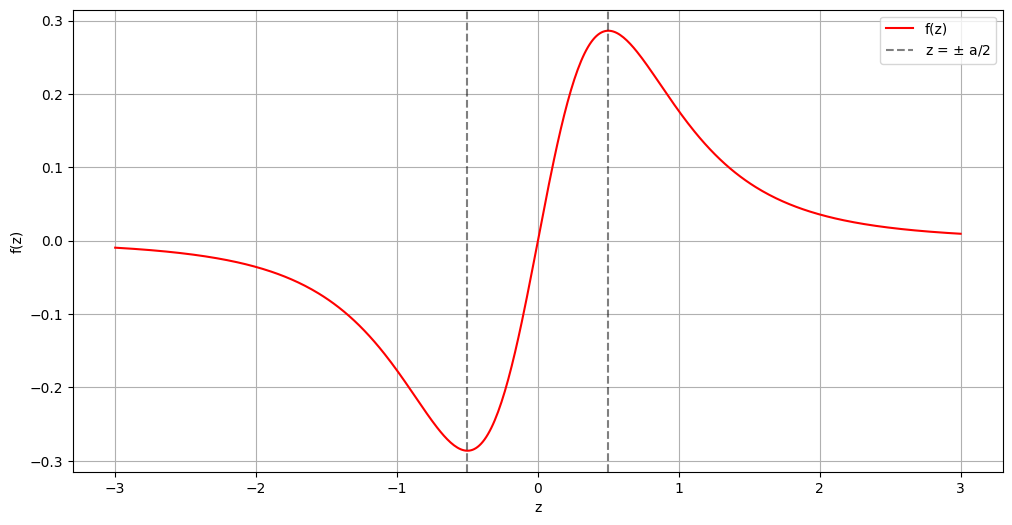

In [30]:
import numpy as np
import matplotlib.pyplot as plt

# Definir el radio a
a = 1

# Definir la función f(z)
def f(z, a):
    return z / (z**2 + a**2)**(5/2)

# Generar puntos para el eje z
z_values = np.linspace(-3, 3, 500) # 500 puntos entre -3 y 3

# Calcular los valores de f(z)
f_values = f(z_values, a)

# Crear el plot
plt.figure(figsize=(12, 6))
plt.plot(z_values, f_values, label=r'f(z)', color='red')

# Añadir las líneas discontinuas
plt.axvline(x=a/2, color='black', linestyle='--', label=r'z = $\pm$ a/2', alpha = 0.5)
plt.axvline(x=-a/2, color='black', linestyle='--', label='_nolegend_', alpha = 0.5)

""" Añadir la línea sólida para los ejes
plt.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
"""

plt.grid(True)

# Etiquetas y título
plt.xlabel('z')
plt.ylabel('f(z)')

# Mostrar leyenda
plt.legend()

# Mostrar el gráfico
plt.show()

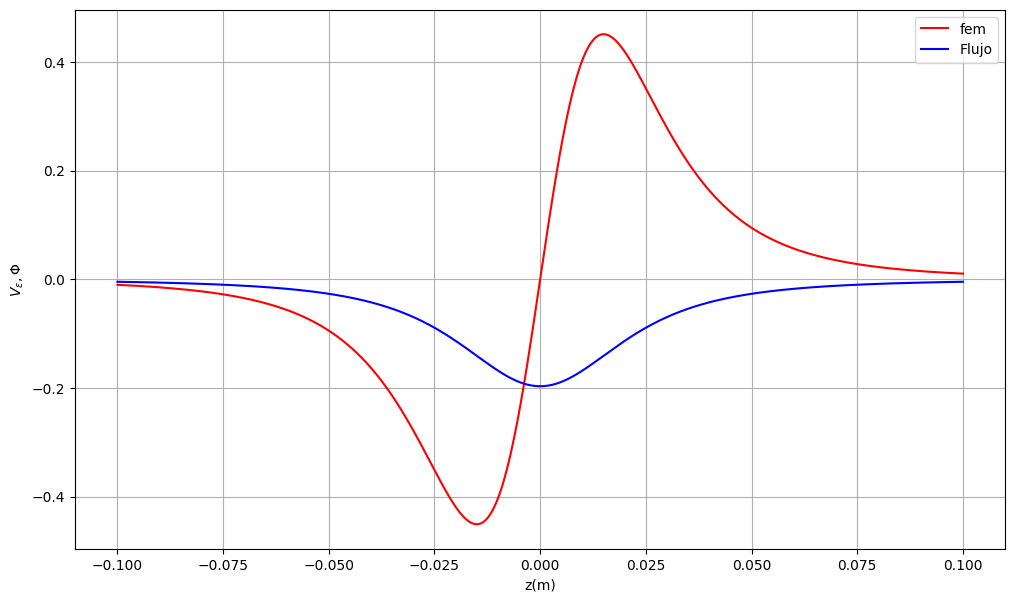

In [34]:
import numpy as np
import matplotlib.pyplot as plt

# Definir las constantes desde el código MATLAB
a = 0.03 # radio de la bobina
N = 400  # número de espiras
v = 0.80 # velocidad del imán
m = 2.35 # momento magnético del imán

# Definir las funciones en Python
mu0 = 4 * np.pi * 1e-7 # Constante de permeabilidad del vacío

def flujo(z, a, N, m, mu0):
    return -10 * mu0 * m * N * a**2 / (2 * (a**2 + z**2)**(3/2))

def fem(z, a, N, m, v, mu0):
    return 3 * mu0 * m * N * a**2 * z * v / (2 * (a**2 + z**2)**(5/2))

# Generar puntos para el eje z en el rango [-0.1, 0.1]
z_values = np.linspace(-0.1, 0.1, 500) # 500 puntos para una curva suave

# Calcular los valores de las funciones
flujo_values = flujo(z_values, a, N, m, mu0)
fem_values = fem(z_values, a, N, m, v, mu0)

# Generación del plot
plt.figure(figsize=(12, 7))

# Plotear ambas funciones
plt.plot(z_values, fem_values, color='red',label='fem')
plt.plot(z_values, flujo_values, color='blue', label='Flujo')

# Etiquetas
plt.xlabel('z(m)')
plt.ylabel(r'$V_\epsilon, \Phi$') # Usando notación LaTeX para V_epsilon y Phi

# Activar la cuadrícula
plt.grid(True)

# Mostrar leyenda
plt.legend()

# Mostrar el gráfico
plt.show()